# Finance Analyzer: Example Usage + Logic Walkthrough

This notebook demonstrates a full run of the finance analyzer and explains the logic used in each stage:
1. Load and validate transactions
2. Detect recurring expenses
3. Build historical balance timeline
4. Forecast future balance with an uncertainty range
5. Generate recommendations and plots

In [1]:
from pathlib import Path
import sys

import pandas as pd
from IPython.display import Image, display

# make src importable
repo_root = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
src_path = repo_root / 'src'
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from finance_analyzer import (
    load_transactions,
    identify_recurring_transactions,
    build_balance_timeline,
    forecast_30_day_balance,
    summarize_analysis,
    generate_recommendations,
    plot_spending_categories,
    plot_balance_forecast,
)

## 1) Load Transaction Data

`load_transactions` reads the CSV and validates core fields (`date`, `description`, `amount`, `category`). It also parses numeric/date values and sorts transactions by date.

In [ ]:
data_path = repo_root / 'data' / 'mock_transactions_data.csv'
df = load_transactions(str(data_path))

print(f'Rows: {len(df)}')
display(df.head(10))

Rows: 276


,date,description,amount,category,balance
0,2025-10-01,Lunch Spot,-14.82,Dining,2435.18
1,2025-10-01,Online Retail,-85.08,Shopping,2350.10
2,2025-10-01,Rent Payment,-1200.00,Housing,1150.10
3,2025-10-02,Coffee Shop,-13.87,Dining,1136.23
4,2025-10-03,Fuel Station,-41.65,Transport,1094.58
5,2025-10-03,Salary Deposit,1500.00,Income,2594.58
6,2025-10-04,Bookstore,-23.04,Entertainment,2571.54
7,2025-10-04,Fuel Station,-43.66,Transport,2527.88
8,2025-10-04,Grocery Store,-83.18,Groceries,2444.70
9,2025-10-04,Lunch Spot,-18.25,Dining,2426.45


## 2) Detect Recurring Expenses

`identify_recurring_transactions` focuses on negative amounts (expenses), groups similar merchant+amount pairs, and marks a stream as recurring when:
- It appears at least 3 times
- The average day gap is roughly monthly (20 to 40 days)

It then estimates monthly cost as the absolute amount of each recurring debit.

In [3]:
recurring_df = identify_recurring_transactions(df)
print(f'Recurring streams found: {len(recurring_df)}')
display(recurring_df.head(10))

Recurring streams found: 7


,merchant,category,amount,occurrences,avg_days_between,last_seen,next_expected_date,estimated_monthly_cost
0,rent payment,Housing,-1200.00,6,30.2,2026-03-01,2026-03-31,1200.00
1,electric utility,Utilities,-92.00,6,30.2,2026-03-18,2026-04-17,92.00
2,internet bill,Utilities,-65.00,6,30.2,2026-03-20,2026-04-19,65.00
3,gym membership,Health,-45.00,6,30.2,2026-03-11,2026-04-10,45.00
4,netflix,Subscriptions,-15.99,6,30.2,2026-03-06,2026-04-05,15.99
5,spotify,Subscriptions,-10.99,6,30.2,2026-03-09,2026-04-08,10.99
6,cloud storage,Subscriptions,-9.99,6,30.2,2026-03-15,2026-04-14,9.99


## 3) Build Balance Timeline and Forecast

`build_balance_timeline` creates a historical running balance. If a `balance` column exists and is complete, that is used directly; otherwise it computes cumulative sum from `amount`.

`forecast_30_day_balance` uses daily net cash flow from recent history to project forward:
- Predicted balance grows by drift: `day_index * avg_daily_net`
- Forecast range expands with uncertainty: `sqrt(day_index) * std_daily_net`
- Lower bound = predicted - uncertainty
- Upper bound = predicted + uncertainty

In [4]:
balance_df = build_balance_timeline(df)
forecast_df = forecast_30_day_balance(df, days=30)

print('Historical timeline (last 5 rows):')
display(balance_df.tail(5))
print('Forecast (first 10 rows):')
display(forecast_df.head(10))

Historical timeline (last 5 rows):


,date,amount,running_balance,category,description
271,2026-03-18,-19.48,354.96,Transport,Fuel Station
272,2026-03-19,-11.71,343.25,Transport,Fuel Station
273,2026-03-20,-65.00,278.25,Utilities,Internet Bill
274,2026-03-20,-14.73,263.52,Transport,Ride Share
275,2026-03-20,1500.00,1763.52,Income,Salary Deposit


Forecast (first 10 rows):


,date,predicted_balance,lower_bound,upper_bound
0,2026-03-21,1795.029333,1275.785364,2314.273303
1,2026-03-22,1826.538667,1092.216803,2560.860530
2,2026-03-23,1858.048000,958.691064,2757.404936
3,2026-03-24,1889.557333,851.069395,2928.045272
4,2026-03-25,1921.066667,760.001854,3082.131479
5,2026-03-26,1952.576000,680.693223,3224.458777
6,2026-03-27,1984.085333,610.294921,3357.875746
7,2026-03-28,2015.594667,546.950939,3484.238394
8,2026-03-29,2047.104000,489.372092,3604.835908
9,2026-03-30,2078.613333,436.619729,3720.606938


## 4) Summary and Recommendations

`summarize_analysis` compacts key outputs into a summary object, and `generate_recommendations` turns recurring and spending signals into practical text guidance.

In [5]:
from dataclasses import asdict

summary = summarize_analysis(df, recurring_df, forecast_df)
recommendations = generate_recommendations(df, recurring_df)

display(pd.DataFrame([asdict(summary)]))
print('Recommendations:\n')
print(recommendations)

,recurring_count,monthly_recurring_cost,current_balance,projected_balance_30d,average_daily_net
0,7,1438.97,1763.52,2708.8,31.509333


Recommendations:

Detected 7 recurring payments totaling €1,438.97/month.
Current balance is €1,763.52; projected 30-day balance is €2,708.80.
Cash flow looks stable. Consider allocating part of surplus to savings or debt payoff.
Highest spending category is 'Housing' at about €7,200.00.
Review recurring subscriptions and cancel any inactive services.
Use a weekly budget check-in to keep spending aligned with your target balance.


## 5) Generate Visuals

Two plots are generated:
- Spending categories pie chart
- Historical vs forecast balance line chart with shaded forecast range

Saved: /home/mohammad/github/finance_analyzer/outputs/notebook/spending_categories.png
Saved: /home/mohammad/github/finance_analyzer/outputs/notebook/balance_forecast.png


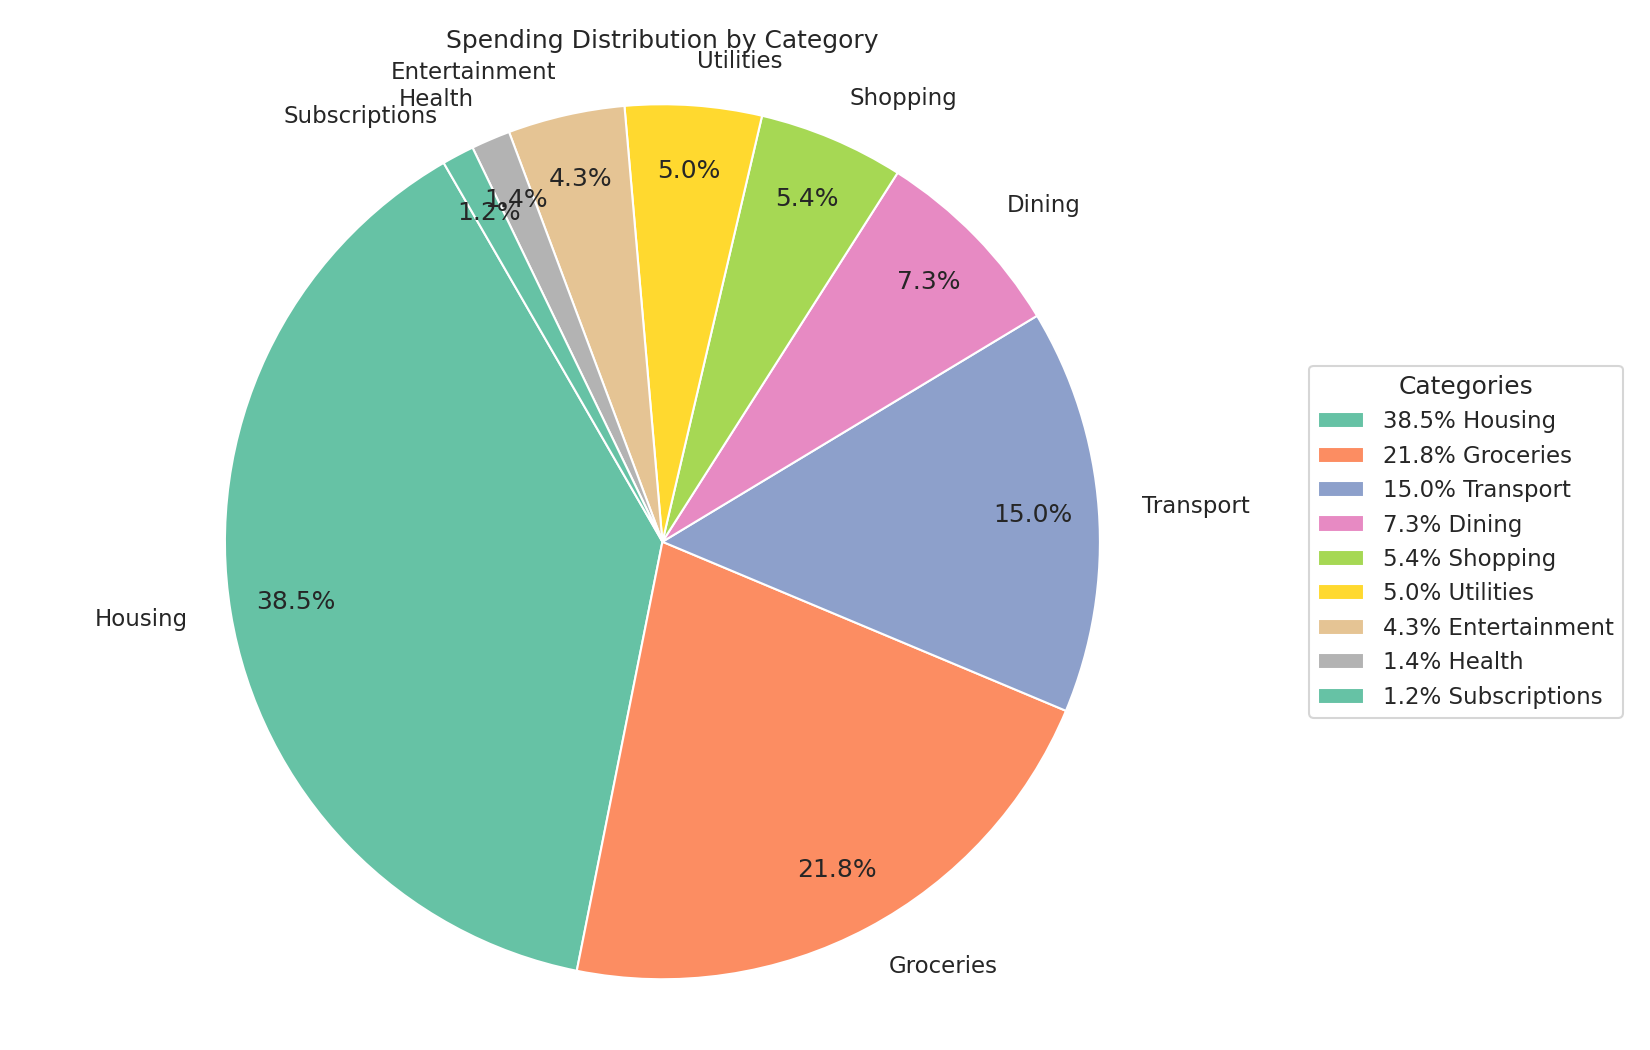

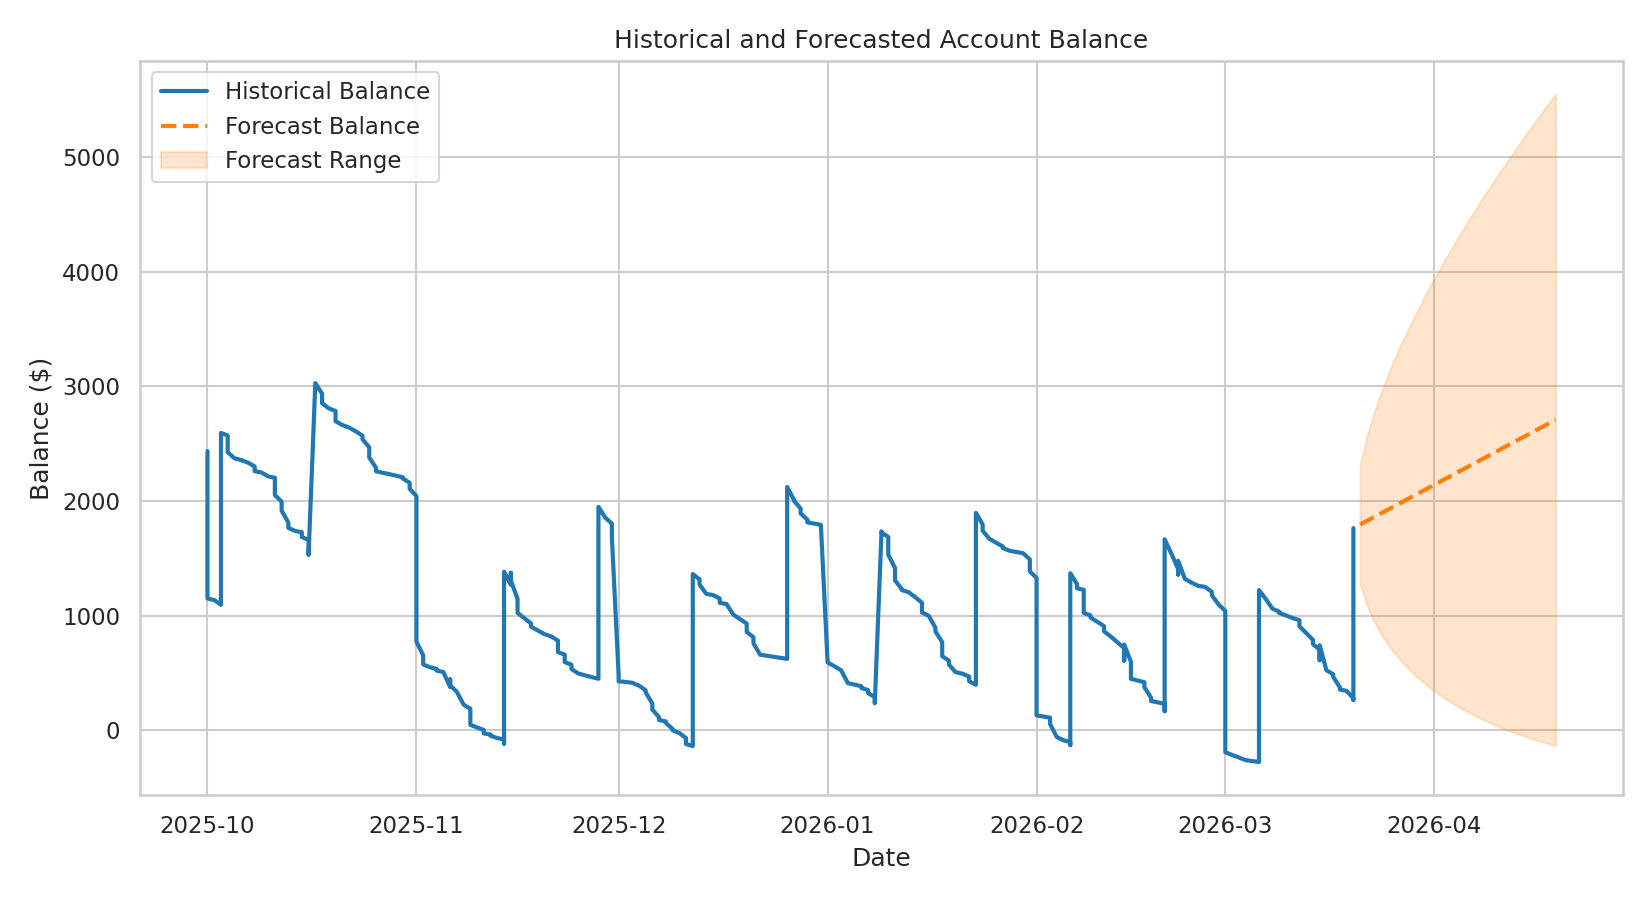

In [6]:
output_dir = repo_root / 'outputs' / 'notebook'
output_dir.mkdir(parents=True, exist_ok=True)

spending_plot = plot_spending_categories(df, str(output_dir / 'spending_categories.png'))
forecast_plot = plot_balance_forecast(balance_df, forecast_df, str(output_dir / 'balance_forecast.png'))

print(f'Saved: {spending_plot}')
print(f'Saved: {forecast_plot}')
display(Image(filename=spending_plot))
display(Image(filename=forecast_plot))

## Interpreting the Forecast Range

The shaded area around forecast balance is not a guaranteed interval; it is a variability band based on recent day-to-day cash-flow volatility.

As forecast horizon increases, uncertainty grows with the square root of time, so the band widens for later days.